# The Fourth Circle: Neural Networks, Part Two 
## Convolutional Neural Networks VI: ResNet

<br/>
Jiří Fejlek

2026-03-13
<br/>

In this smaller project, we will introduce ResNet from 2015 [[1](#1)], which won the 2015 ImageNet Large Scale Visual Recognition Challenge (ILSVRC). As convolutional neural network architectures grew deeper and deeper, their training became increasingly difficult. It was observed that training deeper neural networks actually the training error actually started to *increase*. While a deeper network is usually more expressive, and thus, "better" than a shallower one, the larger deeper network does not necessarily encompass the shallower one. This means that in general, a deeper network is simply different, and thus it might actually be "worse."


The solution to these issues with very deep neural network architectures proved to be actually quite simple and elegant: *residual* (also known as skip) connections. These allow signals to skip some layers, effectively reducing the network's depth if needed. 


## Table of Contents

- [ResNet](#resnet)
    - [Residual Block](#resnet-block)
    - [ResNet-18](#ResNet-18)
    - [ResNet-50](#ResNet-50)
    - [Custom ResNets for Fashion-MNIST and CIFAR-10](#ResNet-custom)
    - [Stochastic Depth](#stochdepth)
- [References](#references)


## ResNet <a class="anchor" id="resnet"></a>

We start with an implementation of the original ResNet architecture [[1](#1)]. Let us first repeat our block of functions we used for training CNNs in the previous projects.

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

import torchvision
import torch

from torch import nn
from torch.utils.data import DataLoader

np.set_printoptions(legacy='1.25')

In [2]:
cuda_device = torch.device('cuda')
torch.cuda.get_device_name(cuda_device)

'NVIDIA GeForce RTX 4070 Ti'

In [3]:
def layer_summary(nn_model, X_shape):
    X = torch.randn(*X_shape)
    for layer in nn_model.net_stack:
        X = layer(X)
        print(layer.__class__.__name__, 'output shape:\t', X.shape)

In [4]:
def init_weights_he(model):
    if isinstance(model, nn.Linear):
        nn.init.kaiming_normal_(model.weight, nonlinearity = 'relu') 
        nn.init.constant_(model.bias, 0) 
    if isinstance(model, nn.Conv2d):
        nn.init.kaiming_normal_(model.weight, nonlinearity = 'relu') 
        nn.init.constant_(model.bias, 0)  

In [5]:
def train_test_loop_cuda(train_data_loader, test_data_loader, model, loss_fn, optimizer, scheduler):
    
    softmax = torch.nn.Softmax(dim = 1)
    model.train()

    loss_sum_train  = 0
    accu_sum_train = 0
    size_train = 0

    
    for batch, (X, y) in enumerate(train_data_loader):

        X = X.to(cuda_device)
        y = y.to(cuda_device)

        optimizer.zero_grad() # zero out the gradients
        
        pred_logits = model(X) # forward pass
        loss = loss_fn(pred_logits, y) # loss evaluation 

        # Backpropagation
        loss.backward() # gradient evaluation
        optimizer.step() # SGD step
        

        # compute prediction epoch loss and accuracy
        with torch.no_grad(): # we do not need to compute the gradients
            loss_sum_train = loss_sum_train + loss*len(X)
            size_train = size_train + len(X)
            accu_sum_train = accu_sum_train + ((softmax(pred_logits).argmax(dim = 1)-y).abs() == 0).long().sum()

    # evaluate performance on the test set
    with torch.no_grad(): 
        
        loss_sum_train = loss_sum_train/size_train
        accu_sum_train = accu_sum_train/size_train
        
        model.eval() 
        loss_sum_test  = 0
        accu_sum_test = 0
        size_test = 0
        
        for batch, (X_test, y_test) in enumerate(test_data_loader):

            X_test = X_test.to(cuda_device)
            y_test = y_test.to(cuda_device)
            
            pred_logits_test = model(X_test)
            loss_sum_test = loss_sum_test + loss_fn(pred_logits_test, y_test)*len(X_test)
            accu_sum_test = accu_sum_test + ((softmax(pred_logits_test).argmax(dim = 1)-y_test).abs() == 0).long().sum()
            size_test = size_test + len(X_test)

        loss_sum_test = loss_sum_test/size_test
        accu_sum_test = accu_sum_test/size_test
        
    # learning rate step; we use loss_sum_train for ReduceLROnPlateau
    learning_rate = scheduler.get_last_lr() 
    scheduler.step() 
    
    return  loss_sum_train.detach(), loss_sum_test.detach(), learning_rate[0], accu_sum_train.detach(), accu_sum_test.detach()

### Residual Block <a class="anchor" id="resnet-block"></a>

ResNet architecture is made by stacking the following residual blocks [[1](#1)].

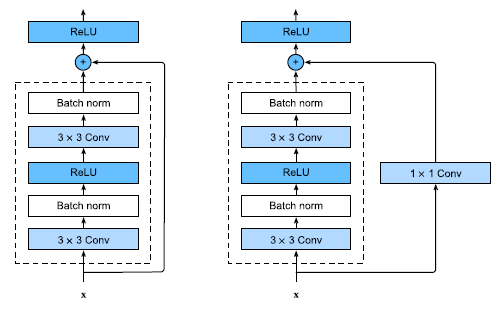

The input to the residual block is split into two branches. One branch consists of a usual stack of convolution layers. However, the second branch skips them. The output of the residual block is then a sum of these two branches. We notice that there are two versions of the residual block: we use the version with 1x1 convolution blocks when we want to change the number of output channels.

In [6]:
class Residual_block(nn.Module):

    def __init__(self, num_channels, strides = 1,  conv1x1 = False):
        super().__init__()

        # Branch 1
        self.b1 = nn.Sequential(nn.LazyConv2d(num_channels, kernel_size=3, padding=1, stride = strides), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(num_channels, kernel_size=3, padding=1, stride = 1), nn.LazyBatchNorm2d()
        )

         # Branch 2
        if conv1x1 == True:
            self.b2 = nn.LazyConv2d(num_channels, kernel_size=1, stride = strides)
        else:
            self.b2 = None

    def forward(self, X):

        b1_x = self.b1(X)
        
        if self.b2:
            X = self.b2(X)

        b1_x += X

        return torch.nn.functional.relu(b1_x)

### ResNet-18 <a class="anchor" id="ResNet-18"></a>

Let us implement several ResNet networks based on the following table from the original paper [[1](#1)]. 

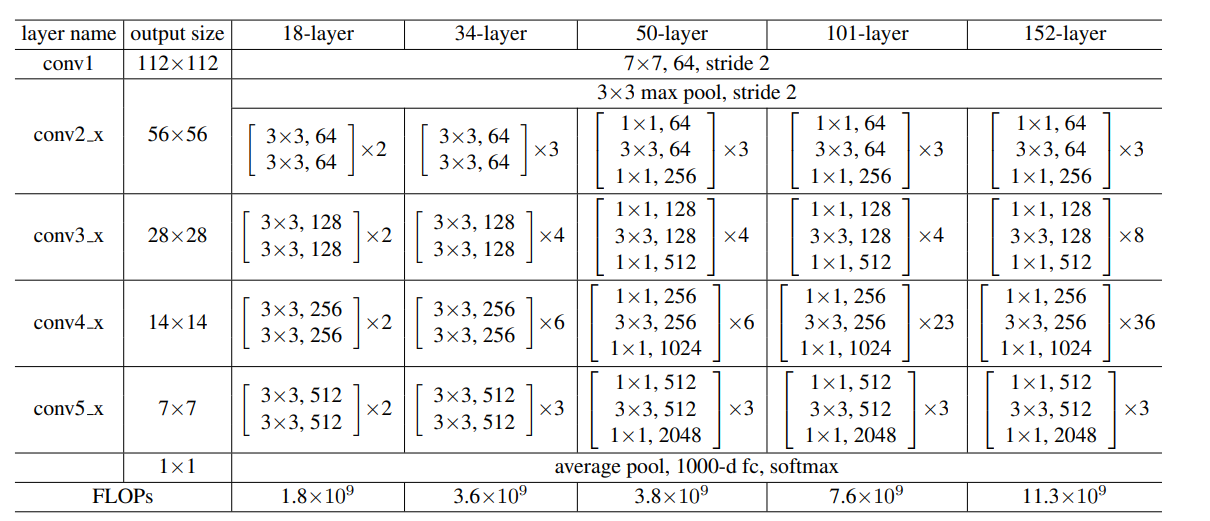

We observe that these architectures are very VGGNet-like [[2](#2)]. 

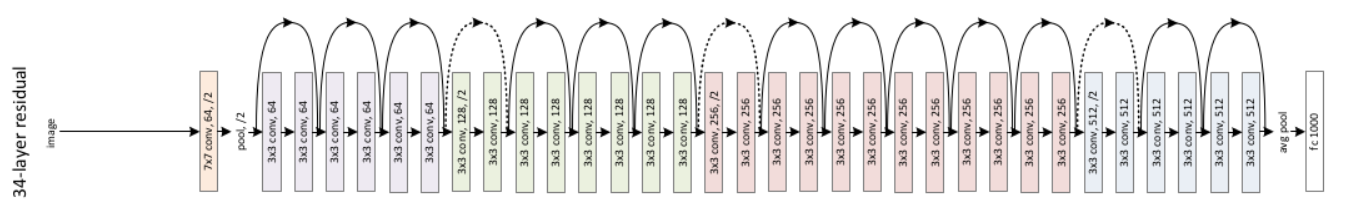

Our ResNet-18 implementation is as follows.

In [7]:
class ResNet_18(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

         # block 1
        self.b1 = nn.Sequential(
            nn.LazyConv2d(64, kernel_size=7, stride=2, padding=3),  nn.LazyBatchNorm2d(), nn.ReLU(), 
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
        
        # residual blocks
        self.b2 =  nn.Sequential(
            Residual_block(64),
            Residual_block(64),
            Residual_block(128, strides = 2, conv1x1 = True),
            Residual_block(128),
            Residual_block(256, strides = 2, conv1x1 = True),
            Residual_block(256),
            Residual_block(512, strides = 2, conv1x1 = True),
            Residual_block(512),
        )

        self.net_stack = nn.Sequential(
            self.b1, self.b2,  nn.AdaptiveAvgPool2d((1,1)), nn.Flatten(),
            nn.LazyLinear(num_classes)
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [8]:
layer_summary(ResNet_18(10),(1, 1, 64, 64))

Sequential output shape:	 torch.Size([1, 64, 16, 16])
Sequential output shape:	 torch.Size([1, 512, 2, 2])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 512, 1, 1])
Flatten output shape:	 torch.Size([1, 512])
Linear output shape:	 torch.Size([1, 10])


As usual, these architectures were made for large images of the ImageNet dataset. Hence, we will use these unmodified networks on the upscaled Fashion-MNIST dataset [[3](#3)].

In [9]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size = [64, 64], scale = [0.9,1.1]) 
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([64,64]),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False)  


# resnet initialization
ResNet_cuda = ResNet_18(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
ResNet_cuda(x);
ResNet_cuda.apply(init_weights_he);

In [10]:
sum(p.numel() for p in ResNet_cuda.parameters() if p.requires_grad)

11178378

In [11]:
optim_SGD_cuda =  torch.optim.SGD(ResNet_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[35], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, ResNet_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

1637.5473573207855


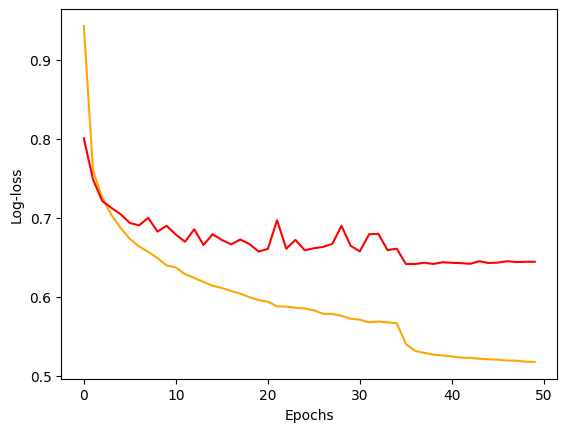

In [12]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

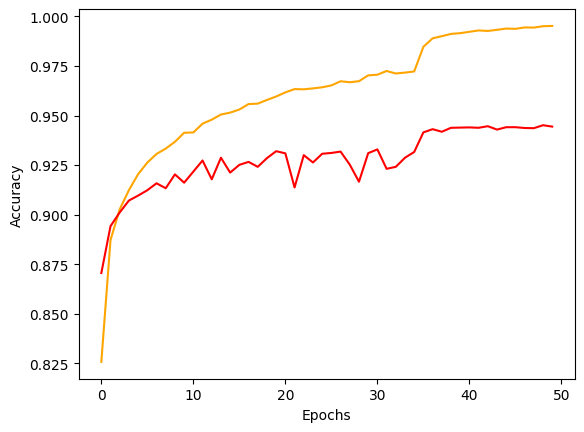

In [13]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

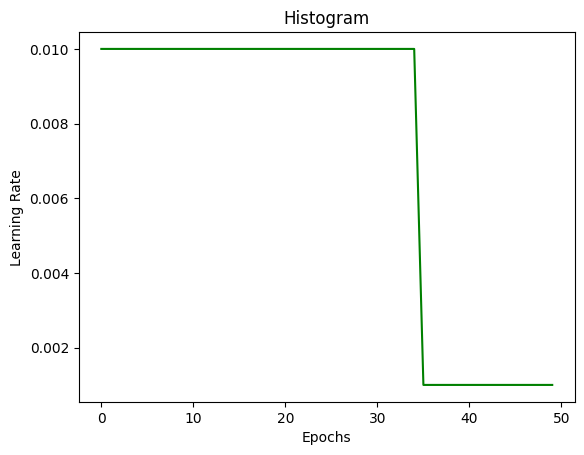

In [14]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [15]:
accu_epochs_train[49]

0.9952000379562378

In [16]:
accu_epochs_test[49]

0.9443999528884888

In [17]:
accu_epochs_test.max()

0.945099949836731

We obtained a respectable performance from the get-go.

### ResNet-50 <a class="anchor" id="ResNet-50"></a>

Next, we will implement ResNet-50. As can be seen from the table of the various ResNet architectures, ResNet-50 includes so-called bottleneck blocks [[1](#1)].

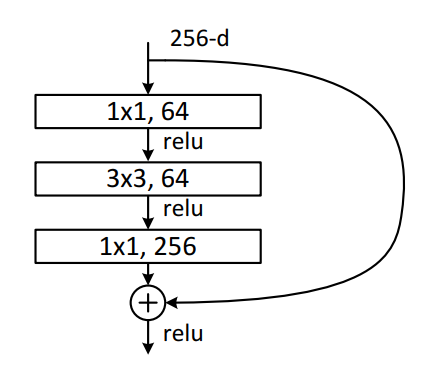

In [18]:
class Residual_bottleneck_block(nn.Module):

    def __init__(self, num_channels, strides = 1,  conv1x1 = False):
        super().__init__()

        # Branch 1
        self.b1 = nn.Sequential(
            nn.LazyConv2d(num_channels[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(num_channels[1], kernel_size=3, padding=1, stride = strides), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(num_channels[2], kernel_size=1), nn.LazyBatchNorm2d()
        )

         # Branch 2
        if conv1x1 == True:
            self.b2 = nn.LazyConv2d(num_channels[2], kernel_size=1, stride = strides)
        else:
            self.b2 = None

    def forward(self, X):

        b1_x = self.b1(X)
        
        if self.b2:
            X = self.b2(X)

        b1_x += X

        return torch.nn.functional.relu(b1_x)

Otherwise, the implementation is pretty straightforward.

In [19]:
class ResNet_50(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

         # block 1
        self.b1 = nn.Sequential(
            nn.LazyConv2d(64, kernel_size=7, stride=2, padding=3),  nn.LazyBatchNorm2d(), nn.ReLU(), 
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
        
        # residual blocks
        self.b2 =  nn.Sequential(
            Residual_bottleneck_block([64,64,256], strides = 1, conv1x1 = True),
            Residual_bottleneck_block([64,64,256]),
            Residual_bottleneck_block([64,64,256]),
            Residual_bottleneck_block([128,128,512], strides = 2, conv1x1 = True),
            Residual_bottleneck_block([128,128,512]),
            Residual_bottleneck_block([128,128,512]),
            Residual_bottleneck_block([128,128,512]),
            Residual_bottleneck_block([256,256,1024], strides = 2, conv1x1 = True),
            Residual_bottleneck_block([256,256,1024]),
            Residual_bottleneck_block([256,256,1024]),
            Residual_bottleneck_block([256,256,1024]),
            Residual_bottleneck_block([256,256,1024]),
            Residual_bottleneck_block([256,256,1024]),
            Residual_bottleneck_block([512,512,2048], strides = 2, conv1x1 = True),
            Residual_bottleneck_block([512,512,2048]),
            Residual_bottleneck_block([512,512,2048])
        )

        self.net_stack = nn.Sequential(
            self.b1, self.b2,  nn.AdaptiveAvgPool2d((1,1)), nn.Flatten(),
            nn.LazyLinear(num_classes)
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [20]:
layer_summary(ResNet_50(10),(1, 1, 64, 64))

Sequential output shape:	 torch.Size([1, 64, 16, 16])
Sequential output shape:	 torch.Size([1, 2048, 2, 2])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 2048, 1, 1])
Flatten output shape:	 torch.Size([1, 2048])
Linear output shape:	 torch.Size([1, 10])


Let us train ResNet-50 on the same problem as ResNet-18.

In [21]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size = [64, 64], scale = [0.9,1.1]) 
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([64,64]),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False)

# resnet initialization
ResNet_cuda = ResNet_50(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
ResNet_cuda(x);
ResNet_cuda.apply(init_weights_he);

In [22]:
sum(p.numel() for p in ResNet_cuda.parameters() if p.requires_grad)

23541130

In [23]:
optim_SGD_cuda =  torch.optim.SGD(ResNet_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[35], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, ResNet_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

1829.1204872131348


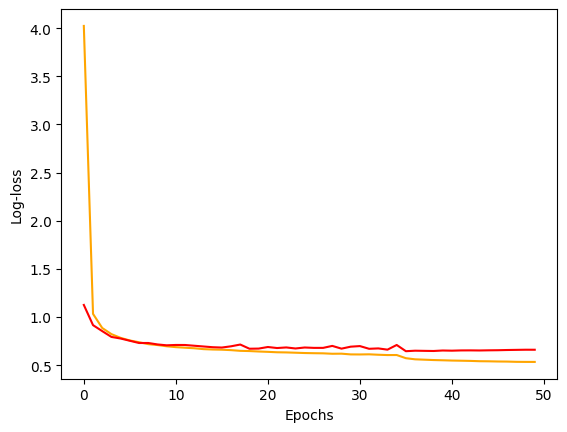

In [24]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

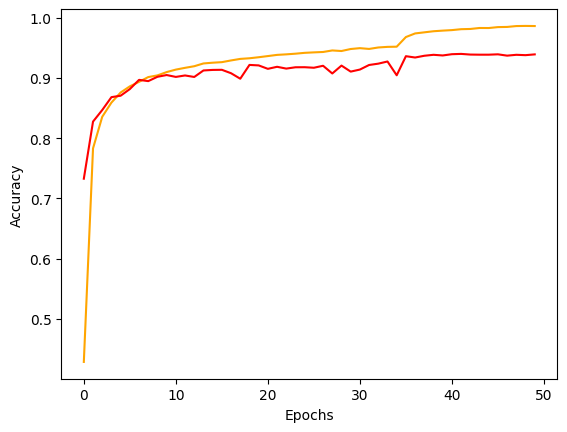

In [25]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

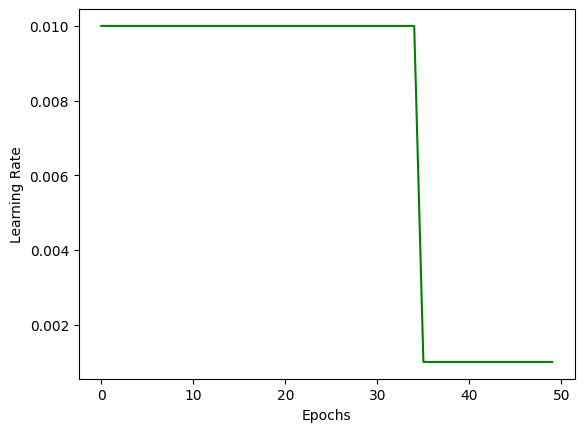

In [26]:
plt.plot(learning_rates, color = 'green')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [27]:
accu_epochs_train[49]

0.9861500263214111

In [28]:
accu_epochs_test[49]

0.9390999674797058

In [29]:
accu_epochs_test.max()

0.9398999810218811

The performance is slightly worse. We would probably need to dedicate more training epochs to obtain the same performance as with the smaller Resnet-18. 

### Custom ResNets for Fashion-MNIST and CIFAR-10 <a class="anchor" id="ResNet-custom"></a>

Let us now design a new ResNet network better tuned for the Fashion-MNIST dataset.

In [30]:
class ResNet_31(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        # residual blocks
        self.b =  nn.Sequential(
            Residual_block(128, strides = 1, conv1x1 = True),
            Residual_block(128),
            Residual_block(128),
            Residual_block(128),
            Residual_block(128),
            Residual_block(256, strides = 2, conv1x1 = True),
            Residual_block(256),
            Residual_block(256),
            Residual_block(256),
            Residual_block(256),
            Residual_block(512, strides = 2, conv1x1 = True),
            Residual_block(512),
            Residual_block(512),
            Residual_block(512),
            Residual_block(512),
        )

        self.net_stack = nn.Sequential(
            self.b,  nn.AdaptiveAvgPool2d((1,1)), nn.Flatten(),
            nn.LazyLinear(num_classes)
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [31]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size = [28, 28], scale = [0.9,1.1]) 
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([28,28]),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False)

# resnet initialization
ResNet_cuda = ResNet_31(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
ResNet_cuda(x);
ResNet_cuda.apply(init_weights_he);

In [32]:
sum(p.numel() for p in ResNet_cuda.parameters() if p.requires_grad)

29541770

In [33]:
optim_SGD_cuda =  torch.optim.SGD(ResNet_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[35], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, ResNet_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

3187.0245475769043


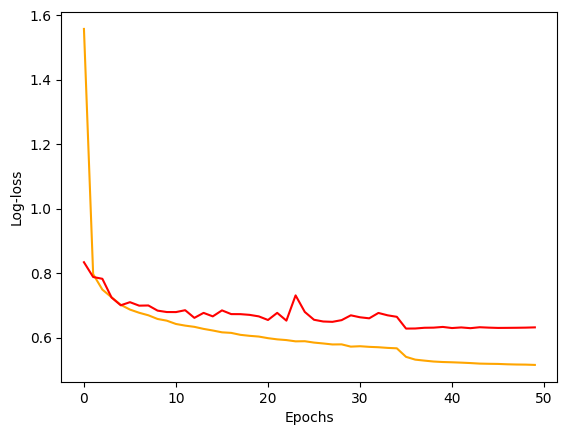

In [34]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

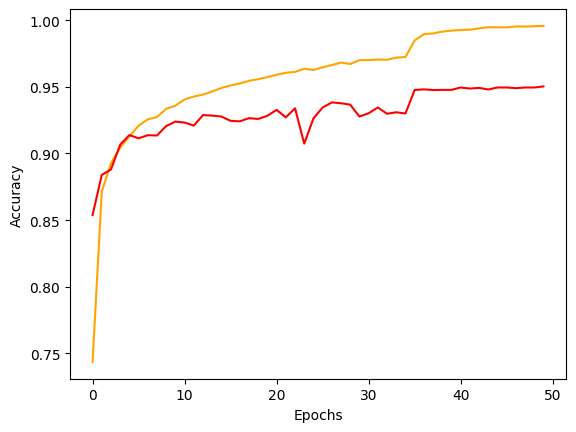

In [35]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

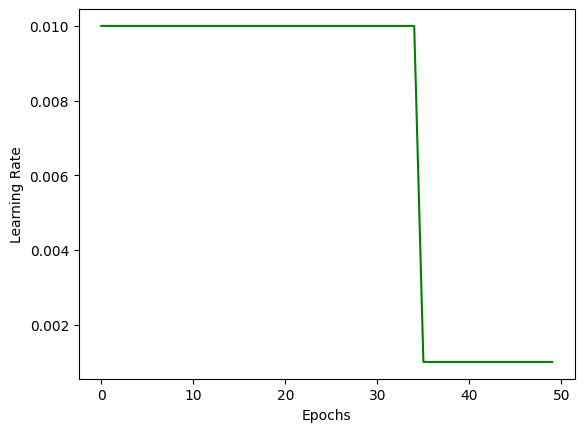

In [36]:
plt.plot(learning_rates, color = 'green')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [37]:
accu_epochs_train[49]

0.9956666827201843

In [38]:
accu_epochs_test[49]

0.9502999782562256

In [39]:
accu_epochs_test.max()

0.9502999782562256

We managed to do slightly better than with ResNet-11. This is our best model on the Fashion MNIST dataset so far.

Next, let us move to the CIFAR-10 dataset (https://www.cs.toronto.edu/~kriz/cifar.html). We should note that the original paper [[1](#1)] describes several ResNet architectures for CIFAR-10, achieving respectable accuracy over 93%. However, these models are fairly large and would take several hours to train on a single GPU. Hence, we will demonstrate a slightly smaller ResNet network that reached over 92% accuracy in just two hour of training.

In [40]:
torch.manual_seed(123)

transforms_cifar10_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616]),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size=[32,32], scale = [0.8, 1.4]),
    ]
)

transforms_cifar10_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616])]
)

cifar10_train = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_cifar10_train)
cifar10_test = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_cifar10_test)


cifar10_train_loader = DataLoader(dataset = cifar10_train, batch_size = 250, shuffle = True) 
cifar10_test_loader = DataLoader(dataset = cifar10_test, batch_size = 250, shuffle = False)

# resnet initialization
ResNet_cuda = ResNet_31(10).to(cuda_device)

x = (cifar10_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
ResNet_cuda(x);
ResNet_cuda.apply(init_weights_he);


optim_SGD_cuda =  torch.optim.SGD(ResNet_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[60, 85], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 100

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]  = train_test_loop_cuda(cifar10_train_loader, cifar10_test_loader, ResNet_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

7055.167746067047


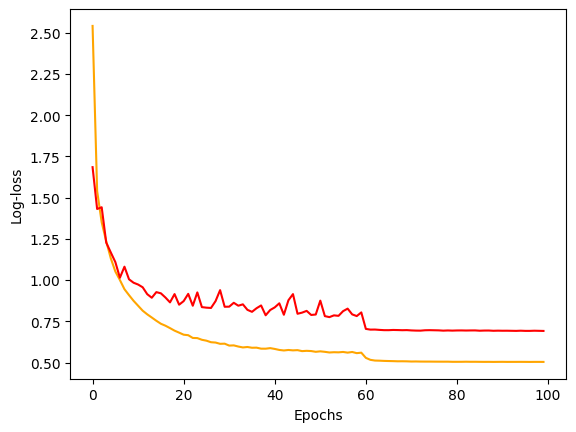

In [41]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

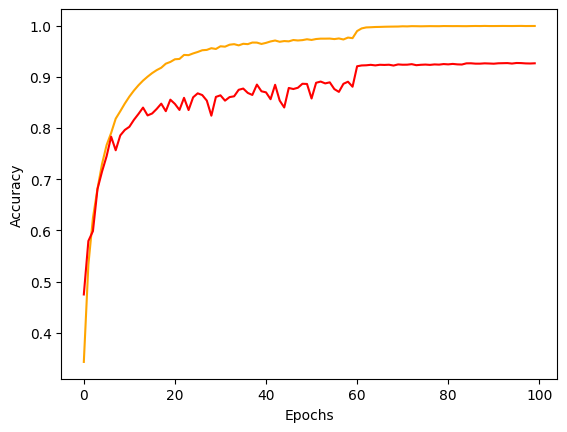

In [42]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

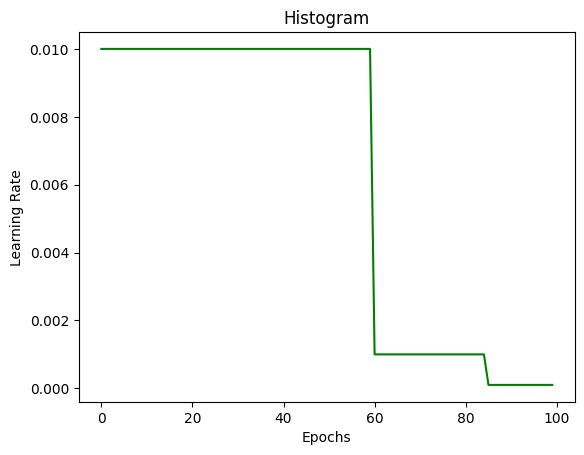

In [43]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [44]:
accu_epochs_train[99]

0.9995399713516235

In [45]:
accu_epochs_test[99]

0.9265999794006348

In [46]:
accu_epochs_test.max()

0.9271999597549438

We have obtained a slightly worse performance than with our VGGnet (93.3% accuracy).

### Stochastic Depth <a class="anchor" id="stochdepth"></a>

There is a small trick, akin to dropout, known as *stochastic depth* that is associated with residual blocks [[4](#4)]. This modification to residual connections is pretty simple: each residual block is ignored during training with some small probability. Consequently, we train a bit shallower network than the final network will be. The numerical experiments showed that ResNet with stochastic depth achieved higher accuracy on benchmarks (almost 95% on CIFAR-10) [[4](#4)].

Sstochastic depth is implemented in PyTorch as follows. 

In [47]:
from torchvision.ops import StochasticDepth

In [48]:
class Residual_block_stochdepth(nn.Module):

    def __init__(self, num_channels, stoch_depth_prob, strides = 1,  conv1x1 = False):
        super().__init__()

        # Branch 1
        self.b1 = nn.Sequential(nn.LazyConv2d(num_channels, kernel_size=3, padding=1, stride = strides), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(num_channels, kernel_size=3, padding=1, stride = 1), nn.LazyBatchNorm2d()
        )

         # Branch 2
        if conv1x1 == True:
            self.b2 = nn.LazyConv2d(num_channels, kernel_size=1, stride = strides)
        else:
            self.b2 = None

        self.stochastic_depth = StochasticDepth(p = stoch_depth_prob, mode = 'row')

    def forward(self, X):

        b1_x = self.stochastic_depth(input = self.b1(X))
        
        if self.b2:
            X = self.b2(X)

        b1_x += X

        return torch.nn.functional.relu(b1_x)

Let us augment our ResNet that we trained on CIFAR-10 with stochastic depth.

In [49]:
class ResNet_31_sch(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        # residual blocks
        self.b =  nn.Sequential(
            Residual_block_stochdepth(128, stoch_depth_prob = 0.2, strides = 1, conv1x1 = True),
            Residual_block_stochdepth(128, stoch_depth_prob = 0.2),
            Residual_block_stochdepth(128, stoch_depth_prob = 0.2),
            Residual_block_stochdepth(128, stoch_depth_prob = 0.2),
            Residual_block_stochdepth(128, stoch_depth_prob = 0.2),
            Residual_block_stochdepth(256, stoch_depth_prob = 0.2, strides = 2, conv1x1 = True),
            Residual_block_stochdepth(256, stoch_depth_prob = 0.2),
            Residual_block_stochdepth(256, stoch_depth_prob = 0.2),
            Residual_block_stochdepth(256, stoch_depth_prob = 0.2),
            Residual_block_stochdepth(256, stoch_depth_prob = 0.2),
            Residual_block_stochdepth(512, stoch_depth_prob = 0.2, strides = 2, conv1x1 = True),
            Residual_block_stochdepth(512, stoch_depth_prob = 0.2),
            Residual_block_stochdepth(512, stoch_depth_prob = 0.2),
            Residual_block_stochdepth(512, stoch_depth_prob = 0.2),
            Residual_block_stochdepth(512, stoch_depth_prob = 0.2)
        )

        self.net_stack = nn.Sequential(
            self.b,  nn.AdaptiveAvgPool2d((1,1)), nn.Flatten(),
            nn.LazyLinear(num_classes)
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [50]:
torch.manual_seed(123)

transforms_cifar10_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616]),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size=[32,32], scale = [0.8, 1.4]),
    ]
)

transforms_cifar10_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616])]
)

cifar10_train = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_cifar10_train)
cifar10_test = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_cifar10_test)


cifar10_train_loader = DataLoader(dataset = cifar10_train, batch_size = 250, shuffle = True) 
cifar10_test_loader = DataLoader(dataset = cifar10_test, batch_size = 250, shuffle = False)

# resnet initialization
ResNet_cuda = ResNet_31_sch(10).to(cuda_device)

x = (cifar10_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
ResNet_cuda(x);
ResNet_cuda.apply(init_weights_he);

optim_SGD_cuda =  torch.optim.SGD(ResNet_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[60, 85], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 100

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]  = train_test_loop_cuda(cifar10_train_loader, cifar10_test_loader, ResNet_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

7248.1983942985535


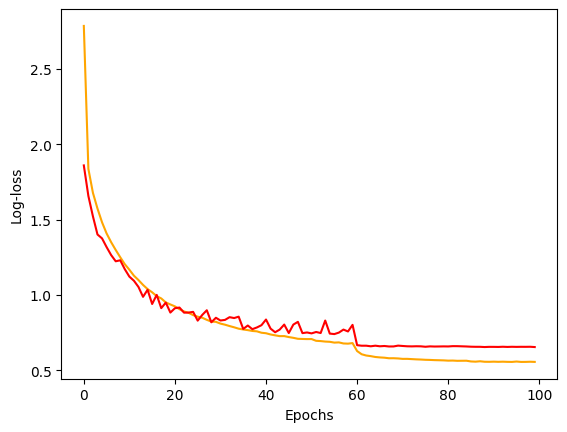

In [51]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

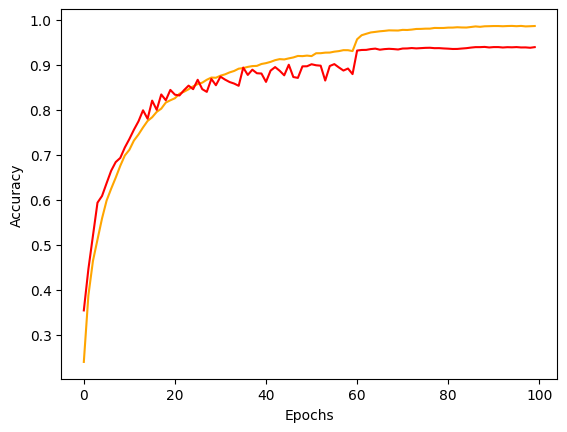

In [52]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

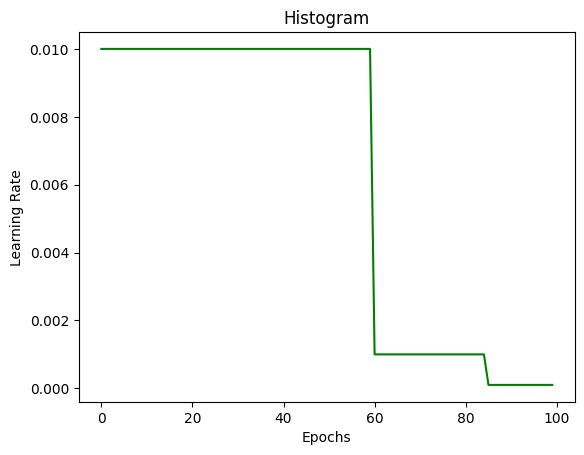

In [53]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [54]:
accu_epochs_train[99]

0.9863199591636658

In [55]:
accu_epochs_test[99]

0.9393999576568604

In [56]:
accu_epochs_test.max()

0.9398999810218811

Stochastic depth helped indeed, we finally reached almost 94% accuracy on the test set. 

## References <a class="anchor" id="references"></a>

<a id="1">[1]</a> HE, Kaiming, et al. Deep residual learning for image recognition. In: Proceedings of the IEEE conference on computer vision and pattern recognition. 2016. p. 770-778.

<a id="2">[2]</a> SIMONYAN, Karen; ZISSERMAN, Andrew. Very deep convolutional networks for large-scale image recognition. *arXiv preprint arXiv:1409.1556*, 2014.

<a id="3">[3]</a> XIAO, Han; RASUL, Kashif; VOLLGRAF, Roland. Fashion-mnist: a novel image dataset for benchmarking machine learning algorithms. arXiv preprint arXiv:1708.07747, 2017.

<a id="4">[4]</a> HUANG, Gao, et al. Deep networks with stochastic depth. In: European conference on computer vision. Cham: Springer International Publishing, 2016. p. 646-661.